In [ ]:
import os

!git clone https://github.com/fagnerrs/UniMed-CLIP.git
%cd UniMed-CLIP
!pip install -r requirements.txt -q

Cloning into 'UniMed-CLIP'...
remote: Enumerating objects: 167, done.
remote: Counting objects: 100% (167/167), done.
remote: Compressing objects: 100% (118/118), done.
remote: Total 167 (delta 58), reused 137 (delta 44), pack-reused 0 (from 0)
Receiving objects: 100% (167/167), 8.32 MiB | 20.57 MiB/s, done.
Resolving deltas: 100% (58/58), done.
/content/UniMed-CLIP
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 120.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.4 MB/s eta 0:00:00


In [ ]:
import sys
sys.path.insert(0, '/content/UniMed-CLIP/src')  # Colab root is always /content

import open_clip
print(open_clip.__file__)

from open_clip import create_model_and_transforms, get_mean_std, HFTokenizer
from unittest.mock import patch

print(open_clip.list_models())

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


/content/UniMed-CLIP/src/open_clip/__init__.py
['RN50', 'RN50-quickgelu', 'RN50x4', 'RN50x16', 'RN101', 'RN101-quickgelu', 'timm-efficientnetv2_rw_s', 'timm-resnet50d', 'timm-resnetaa50d', 'timm-resnetblur50', 'timm-swin_base_patch4_window7_224', 'timm-vit_base_patch16_224', 'timm-vit_base_patch32_224', 'timm-vit_small_patch16_224', 'ViT-B-16', 'ViT-B-16-plus', 'ViT-B-16-plus-240', 'ViT-B-16-quickgelu', 'ViT-B-32', 'ViT-B-32-plus-256', 'ViT-B-32-quickgelu', 'ViT-bigG-14-quickgelu', 'ViT-g-14', 'ViT-H-14', 'ViT-H-14-quickgelu', 'ViT-H-16', 'ViT-L-14', 'ViT-L-14-280', 'ViT-L-14-336', 'ViT-L-14-336-quickgelu', 'ViT-L-14-quickgelu', 'ViT-L-16', 'ViT-L-16-320']


In [ ]:
import torch
from huggingface_hub import hf_hub_download


device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")  # confirm GPU is available in Colab runtime

ckpt_path = "/content/drive/MyDrive/efast-output-dir/10i_10t_20epochs_efast_clip_best.pt"

MODEL_ARCH        = 'ViT-B-16-quickgelu'
text_encoder_name = "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract"
mean, std         = get_mean_std()


# Temporarily monkey-patch torch.load to use weights_only=False
original_load = torch.load

def patched_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return original_load(*args, **kwargs)

with patch('torch.load', patched_load):
    model, _, preprocess = create_model_and_transforms(
        MODEL_ARCH,
        pretrained=ckpt_path,
        precision='amp',
        device=device,
        force_quick_gelu=True,
        mean=mean,
        std=std,
        inmem=True,
        text_encoder_name=text_encoder_name
    )

tokenizer = HFTokenizer(text_encoder_name)
model     = model.to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'UniMed-CLIP ({MODEL_ARCH}) loaded — {n_params/1e6:.1f}M parameters')

Device: cuda


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  440MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/225k [00:00<?, ?B/s]

UniMed-CLIP (ViT-B-16-quickgelu) loaded — 195.9M parameters


### Zero Shooting

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, classification_report
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")

TEST_ANNOTATIONS_PATH = "/content/drive/MyDrive/efast-test-dataset/image-test-annotations.json"
TEST_IMAGES_DIR = "/content/drive/MyDrive/efast-test-dataset"

In [ ]:
def batch_predict(image_filenames, text_prompts, images_dir, batch_size=32):
    """
    Executa o CLIP em lotes sobre `image_filenames` e classifica cada imagem
    de acordo com o prompt de texto (`text_prompts`) de maior probabilidade (softmax).

    Retorna:
        pred_indices: np.ndarray[int]   — índice do prompt vencedor por imagem
        pred_probs:   np.ndarray[float] — probabilidade (confiança) do prompt vencedor
    """
    texts = [tokenizer(p).to(device) for p in text_prompts]
    texts = torch.cat(texts, dim=0)

    with torch.no_grad():
        text_features = model.encode_text(texts)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    pred_indices, pred_probs = [], []

    for start in tqdm(range(0, len(image_filenames), batch_size), desc="Classificando imagens"):
        batch_files = image_filenames[start:start + batch_size]
        batch_imgs = [
            preprocess(Image.open(os.path.join(images_dir, fname)).convert("RGB"))
            for fname in batch_files
        ]
        batch_tensor = torch.stack(batch_imgs).to(device)

        with torch.no_grad():
            image_features = model.encode_image(batch_tensor)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)
            logits = (model.logit_scale.exp() * image_features @ text_features.t()).softmax(dim=-1)
            logits = logits.cpu().numpy()

        pred_indices.extend(logits.argmax(axis=1).tolist())
        pred_probs.extend(logits.max(axis=1).tolist())

    return np.array(pred_indices), np.array(pred_probs)


In [ ]:
from PIL import Image

batch_size = 256

with open(TEST_ANNOTATIONS_PATH, "r") as f:
    annotations = json.load(f)

image_filenames = list(annotations.keys())
true_windows = [annotations[f]["window"] for f in image_filenames]

# Um prompt de texto por classe de janela
window_prompts = [
    "Lung window",
    "Perisplenic (LUQ) window",
    "Pelvic window",
    "Hepatorenal (RUQ) window",
    "Subxiphoid window"
]

# Mapeia o rótulo de 'window' do dataset para a classe de prompt correspondente
# (Pelvic (Male) e Pelvic (Female) são ambas avaliadas contra o prompt único 'Pelvic window')
window_label_map = {
    "Lung": "Lung window",
    "Perisplenic (LUQ)": "Perisplenic (LUQ) window",
    "Pelvic (Male)": "Pelvic window",
    "Pelvic (Female)": "Pelvic window",
    "Hepatorenal (RUQ)": "Hepatorenal (RUQ) window",
    "Subxiphoid": "Subxiphoid window"
}

unmapped = sorted(set(true_windows) - set(window_label_map))
assert not unmapped, f"Valores de 'window' sem mapeamento: {unmapped}"

y_true_window = [window_label_map[w] for w in true_windows]

print(os.path.join(TEST_IMAGES_DIR, image_filenames[0]))

pred_idx_window, pred_prob_window = batch_predict(
    image_filenames=image_filenames,
    text_prompts=window_prompts,
    images_dir=TEST_IMAGES_DIR,
    batch_size=batch_size,
)
y_pred_window = [window_prompts[i] for i in pred_idx_window]

/content/drive/MyDrive/efast-test-dataset/RUQ_10_221_jpg.rf.f01b185053c5b0eb469a46a7aa5a7a0c.jpg


Classificando imagens:   0%|          | 0/9 [00:00<?, ?it/s]

In [ ]:
labels_order = window_prompts

precision_per_class = precision_score(
    y_true_window, y_pred_window, labels=labels_order, average=None, zero_division=0
)

precision_df = pd.DataFrame({
    "window": labels_order,
    "precision": precision_per_class,
    "n_predicted": [y_pred_window.count(w) for w in labels_order],
    "n_true": [y_true_window.count(w) for w in labels_order],
}).sort_values("precision", ascending=False).reset_index(drop=True)

overall_acc_window = float(np.mean(np.array(y_true_window) == np.array(y_pred_window)))

print(classification_report(y_true_window, y_pred_window, labels=labels_order, zero_division=0))
print(f"Acurácia geral: {overall_acc_window * 100:.2f}%")
precision_df


                          precision    recall  f1-score   support

             Lung window       0.00      0.00      0.00       359
Perisplenic (LUQ) window       0.70      0.95      0.81       525
           Pelvic window       1.00      0.55      0.71       544
Hepatorenal (RUQ) window       0.92      0.95      0.94       731
       Subxiphoid window       0.22      0.96      0.36       115

                accuracy                           0.71      2274
               macro avg       0.57      0.68      0.56      2274
            weighted avg       0.71      0.71      0.67      2274

Acurácia geral: 70.58%


,window,precision,n_predicted,n_true
0,Pelvic window,1.000000,297,544
1,Hepatorenal (RUQ) window,0.920740,757,731
2,Perisplenic (LUQ) window,0.698745,717,525
3,Subxiphoid window,0.218688,503,115
4,Lung window,0.000000,0,359


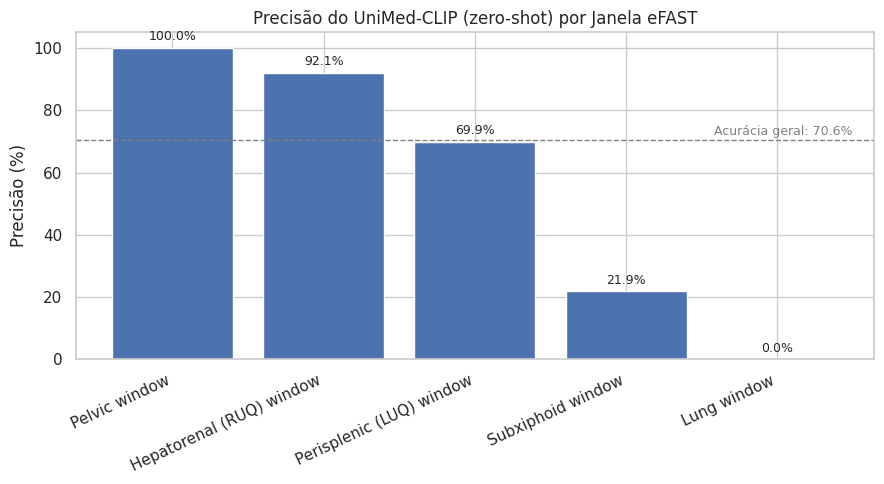

In [ ]:
# --- Dashboard de precisão por janela ---
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(precision_df["window"], precision_df["precision"] * 100, color="#4C72B0")

ax.set_ylim(0, 105)
ax.set_ylabel("Precisão (%)")
ax.set_title("Precisão do UniMed-CLIP (zero-shot) por Janela eFAST")
ax.set_xticks(range(len(precision_df)))
ax.set_xticklabels(precision_df["window"], rotation=25, ha="right")

for bar, val in zip(bars, precision_df["precision"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f"{val * 100:.1f}%", ha="center", va="bottom", fontsize=9)

ax.axhline(overall_acc_window * 100, color="gray", linestyle="--", linewidth=1)
ax.text(len(precision_df) - 0.5, overall_acc_window * 100 + 1.5,
        f"Acurácia geral: {overall_acc_window * 100:.1f}%", ha="right", fontsize=9, color="gray")

plt.tight_layout()
plt.show()


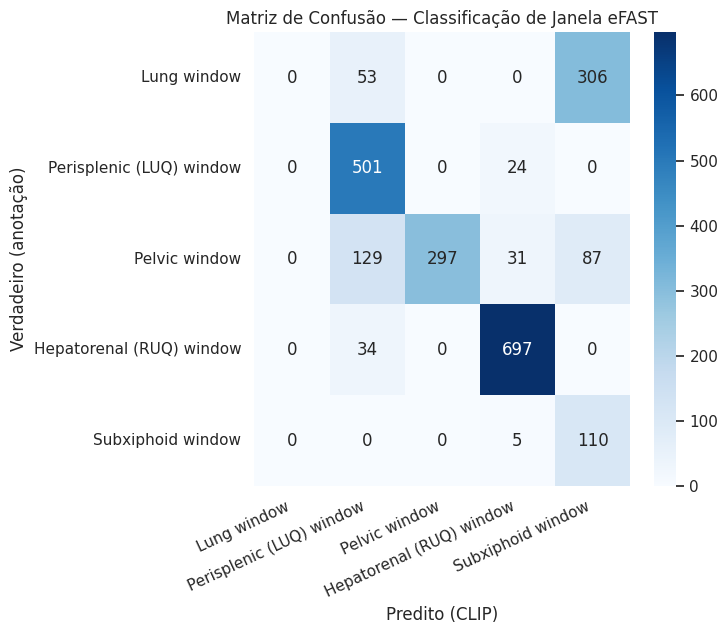

In [ ]:
# --- Matriz de confusão — Janela eFAST ---
cm_window = confusion_matrix(y_true_window, y_pred_window, labels=labels_order)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
sns.heatmap(cm_window, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_order, yticklabels=labels_order, ax=ax, cbar=True)
ax.set_xlabel("Predito (CLIP)")
ax.set_ylabel("Verdadeiro (anotação)")
ax.set_title("Matriz de Confusão — Classificação de Janela eFAST")
plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# Zero shot


In [ ]:
def infer(images, text_prompts):

  texts = [tokenizer(cls_text).to(next(model.parameters()).device, non_blocking=True) for cls_text in text_prompts]
  texts = torch.cat(texts, dim=0)

  # Inference
  with torch.no_grad():
      text_features = model.encode_text(texts)
      text_features = text_features / text_features.norm(dim=-1, keepdim=True)

      image_features = model.encode_image(images)
      image_features = image_features / image_features.norm(dim=-1, keepdim=True)

      logits = (model.logit_scale.exp() * image_features @ text_features.t()).detach().softmax(dim=-1)
      sorted_indices = torch.argsort(logits, dim=-1, descending=True)

      logits = logits.cpu().numpy()

  # Print class probabilities for each image
  top_k = -1

  for i, img in enumerate(test_imgs):
      pred = text_prompts[sorted_indices[i][0]]

      top_k = len(text_prompts) if top_k == -1 else top_k

      print(img.split('/')[-1] + ':')

      for j in range(top_k):
          jth_index = sorted_indices[i][j]
          print(f'{text_prompts[jth_index]}: {logits[i][jth_index]}')

      print('\n')

In [ ]:
from PIL import Image

# Load and preprocess images
test_imgs = [
    'RUQ_10_221_jpg.rf.f01b185053c5b0eb469a46a7aa5a7a0c.jpg',  # Hepatorrenal
    'ESPL-6-02850_jpg.rf.8feafdc0cc306aa071b3182de3bf399a.jpg', # Perisplenic
    'LUNG_12_9411_jpg.rf.9b180086e31f75ca0fb469c39bf08fac.jpg', # Pulmonar
    'PELV-9-03246_jpg.rf.e490e69975b78571b4f5cdc595dd0cb6.jpg', # Pelvic
    'PERI-1-06343_jpg.rf.a7c010ccd73690539295814c76d49d71.jpg' # Subxiphoid
]
images = torch.stack([preprocess(Image.open(("/content/drive/MyDrive/efast-test-dataset/" + img))) for img in test_imgs]).to(device)

In [ ]:
text_prompts = [
    'Efast image Hepatorenal window',
    'Efast image Perisplenic window',
    'Efast image Pulmonar window',
    'Efast image Pelvic window',
    'Efast image Subxiphoid window'
    ]

infer(images, text_prompts)

RUQ_10_221_jpg.rf.f01b185053c5b0eb469a46a7aa5a7a0c.jpg:
Efast image Subxiphoid window: 0.2085953801870346
Efast image Perisplenic window: 0.20541338622570038
Efast image Pulmonar window: 0.20368440449237823
Efast image Pelvic window: 0.19885112345218658
Efast image Hepatorenal window: 0.1834557205438614


ESPL-6-02850_jpg.rf.8feafdc0cc306aa071b3182de3bf399a.jpg:
Efast image Subxiphoid window: 0.20890510082244873
Efast image Perisplenic window: 0.20638006925582886
Efast image Pulmonar window: 0.2035193145275116
Efast image Pelvic window: 0.19844606518745422
Efast image Hepatorenal window: 0.1827494502067566


LUNG_12_9411_jpg.rf.9b180086e31f75ca0fb469c39bf08fac.jpg:
Efast image Subxiphoid window: 0.20804637670516968
Efast image Perisplenic window: 0.20594583451747894
Efast image Pulmonar window: 0.20462296903133392
Efast image Pelvic window: 0.1973186582326889
Efast image Hepatorenal window: 0.1840660721063614


PELV-9-03246_jpg.rf.e490e69975b78571b4f5cdc595dd0cb6.jpg:
Efast image Subxi